# Data

In [1]:
import numpy as np
import pandas  as pd
import os
from IPython.display import clear_output
import pygad
from classes import MACDBacktester, backtest

os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src')
from utils.utils import CreateTimeFrames

os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src\\data')
#os.getcwd()
df = pd.read_csv('BTCUSD_1m_2024-09-23.csv', index_col='time', usecols=['time', 'open', 'high', 'low', 'close', 'tick_volume'])
df.index = pd.to_datetime(df.index)

os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src\\genetic')

price_column = 'close'
date_split = "2024-10-1"
tf = '1h'

timeframes = ['1min','5min','15min', '30min','1h', '4h','1d','1w','1m']
df = CreateTimeFrames(df,timeframes)

working_dataset = df[tf]

df_train = working_dataset[:date_split]
df_test = working_dataset[date_split:]

signal_price = 'close'
real_price = 'close'

clear_output()


# Trade Analyzer

In [ ]:
class MACDBacktester:
    def __init__(self, data, fast_ema, slow_ema, signal_line, signal_price = 'close', real_price = 'close',
                  sell_fee = 0.115, buy_fee = 0.115, initial_capital = 100):
        self.data = data.copy()
        self.fast_ema = fast_ema
        self.slow_ema = slow_ema
        self.signal_line = signal_line
        self.signal_price = signal_price
        self.real_price = real_price
        self.sell_fee_percent = sell_fee / 100
        self.buy_fee_percent = buy_fee / 100
        self.initial_capital = initial_capital
        self.trades = []
        self.data['positions'] = 0
        
    def calculate_macd(self):
        self.data['fast_ema'] = self.data[self.signal_price].ewm(span = self.fast_ema, adjust = False).mean()
        self.data['slow_ema'] = self.data[self.signal_price].ewm(span = self.slow_ema, adjust = False).mean()
        self.data['macd_line'] = self.data['fast_ema'] - self.data['slow_ema']
        self.data['signal_line'] = self.data['macd_line'].ewm(span = self.signal_line, adjust = False).mean()


    def generate_signals(self):
        """
        Generates trading signals based on MACD crossover.
        """
        threshold = 0.1
        self.data['signal'] = 0
        self.data['signal'] = np.where((self.data['macd_line'] - self.data['signal_line']) > threshold, 1, 0) # Buy signal
        self.data['signal'] = np.where((self.data['macd_line'] - self.data['signal_line']) < -threshold, 0, self.data['signal']) # Sell signal
        # Generation the position by shifting the signals
        #self.data['positions'] = self.data['signal'].shift(1).fillna(0)
        self.data['positions'] = self.data['signal']
        return self.data

    def backtest_strategy(self):
        """
        Backtests the strategy and calculates performance metrics.
        """
        self.data['price'] = self.data[self.real_price]
        self.data['positions'] = self.data['positions'].astype(int)
        self.data['positions_diff'] = self.data['positions'].diff()
        self.data['positions_diff'].fillna(0)

        # Initialize cash and holdings
        self.data['cash'] = self.initial_capital
        self.data['holdings'] = 0.0
        self.data['total'] = self.initial_capital


        # Variable to keep track of cash, holdings, trades
        cash = self.initial_capital
        holdings = 0.0
        position = 0  # Current position (number of shares)
        buy_price = 0.0
        win_count = 0  # Win rate calculation
        total_trades = 0

        for idx, row in self.data.iterrows():
            position_change = row['positions_diff']
            price = row['price']
            if position_change == 1: # Long position
                # With regard to the randomness of market, I can decide how much of cash should spend for trading.
                shares_to_buy = round(cash/(price),8)
                shares_to_buy = shares_to_buy * (1-self.buy_fee_percent)

                if shares_to_buy > 0.00002:
                    buy_price = round((cash/shares_to_buy),8) 
                    total_cost = round(shares_to_buy * buy_price, 8)
                    cash -= total_cost
                    holdings += shares_to_buy * price
                    position += shares_to_buy


            elif position_change ==-1 and position > 0: # position is the number of shares.
                # Exit the long position
                sell_price = price * (1-self.sell_fee_percent)
                total_proceeds = position * sell_price
                cash += total_proceeds
                holdings -= position * sell_price
                # Calculate trade return
                trade_return = (sell_price - buy_price)/buy_price * 100
                self.trades.append(trade_return)
                position = 0
                total_trades +=1 # Win rate calculation
                if trade_return>0:
                    win_count +=1
            else:
                # Hold position
                holdings = position * price


            total = cash + holdings
            self.data.at[idx, 'cash'] = float(cash)
            self.data.at[idx, 'holdings'] = holdings
            self.data.at[idx, 'total'] = float(total)

        if position > 0 :
            
            price = self.data.iloc[-1]['price']
            sell_price = price * (1-self.sell_fee_percent)
            total_proceeds = position * sell_price
            cash += total_proceeds
            # Calculate trade return
            trade_return = (sell_price - buy_price) / buy_price * 100
            self.trades.append(trade_return)
            position = 0
            total_trades +=1 # Win rate calculation
            if trade_return>0:
                win_count +=1
            total = cash + holdings
            self.data.at[self.data.index[-1], 'cash'] = cash
            self.data.at[self.data.index[-1], 'holdings'] = holdings
            self.data.at[self.data.index[-1], 'total'] = total

        self.results = self.data[['cash', 'holdings', 'total']]
        self.results = self.data[['cash', 'holdings', 'total']]

        self.win_rate = (win_count / total_trades * 100) if total_trades > 0 else 0
        return self.data

    def get_performance_metrics(self):
        """
        Calculates and returns performance metrics.
        """
        if self.results is None:
            print("Please run backtest_strategy() before calculating performance metrics.")
            return None

        total_return = (self.results['total'].iloc[-1] - self.initial_capital) / self.initial_capital * 100
        returns = self.results['total'].pct_change().fillna(0)
        annualized_return = ((1 + returns.mean()) ** 252 - 1) * 100  # Assuming daily returns
        annualized_volatility = returns.std() * np.sqrt(252) * 100
        sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() != 0 else np.nan
        max_drawdown = ((self.results['total'].cummax() - self.results['total']) / self.results['total'].cummax()).max() * 100

        metrics = {
            'Total Return (%)': total_return,
            'Annualized Return (%)': annualized_return,
            'Annualized Volatility (%)': annualized_volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown (%)': max_drawdown,
            'Win Rate (%)' : self.win_rate
        }
        return metrics, total_return

    def print_trades(self):
        """
        Prints individual trade returns.
        """
        if not self.trades:
            print("No trades have been executed.")
            return
        for idx, trade_return in enumerate(self.trades, 1):
            print(f"Trade {idx}: Return = {trade_return:.2f}%")
        total_return = sum(self.trades)
        print(f"Total Return from trades: {total_return:.2f}%")


In [ ]:
backtester = MACDBacktester(df_train, 7, 22, 8,signal_price='open', real_price='open')
backtester.calculate_macd()
backtester.generate_signals()
backtester.backtest_strategy()
_,total_return = backtester.get_performance_metrics()
print(total_return)
# backtester.print_trades()

# Genetic

c:\Users\arvin\AppData\Local\Programs\Python\Python312\Lib\site-packages\pygad\pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.")
c:\Users\arvin\AppData\Local\Programs\Python\Python312\Lib\site-packages\pygad\pygad.py:1162: UserWarning: Use the 'save_solutions' parameter with caution as it may cause memory overflow when either the number of generations, number of genes, or number of solutions in population is large.
  warnings.warn("Use the 'save_solutions' parameter with caution as it may cause memory overflow when either the number of generations, number o

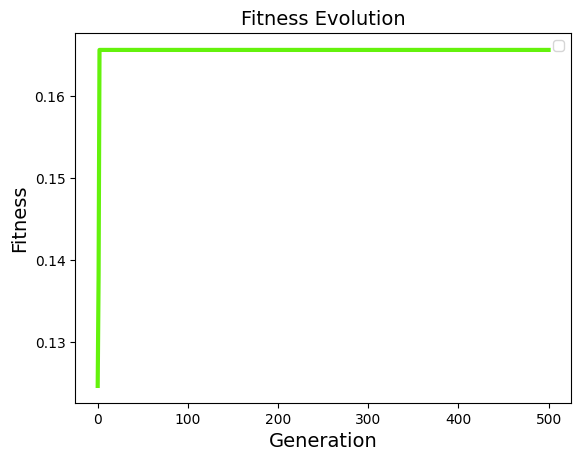

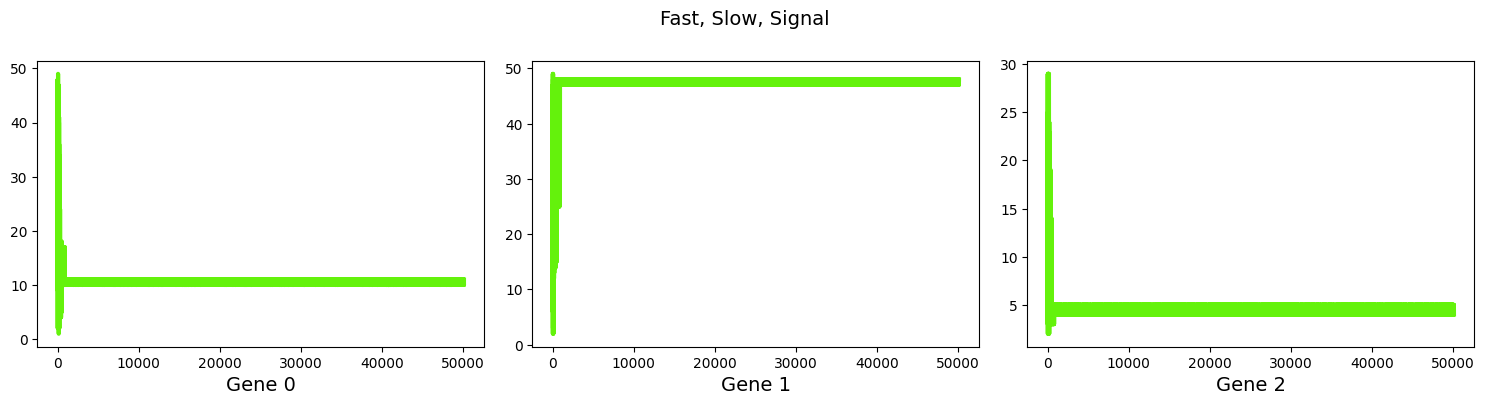

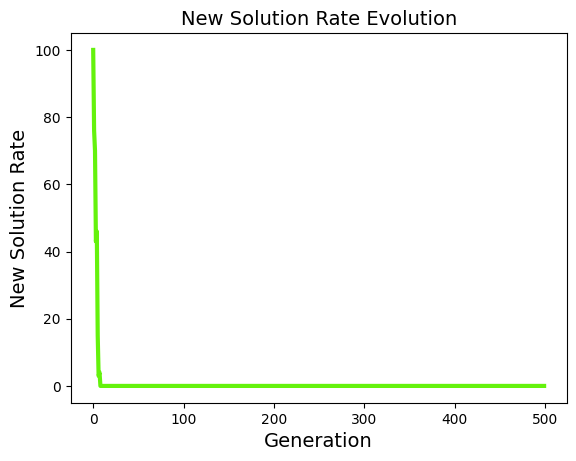

Best Parameters: Fast EMA=11, Slow EMA=48, Signal Line=5
Net Profit: 0.16567742347143388


In [4]:
import pygad

# MACD Calculation
def macd(data, fast, slow, signal):
    data['ema_fast'] = data['close'].ewm(span=fast, min_periods=1, adjust=False).mean()
    data['ema_slow'] = data['close'].ewm(span=slow, min_periods=1,  adjust=False).mean()
    data['macd_line'] = data['ema_fast'] - data['ema_slow']
    data['signal_line'] = data['macd_line'].ewm(span=signal, adjust=False).mean()
    return data


def generate_signals( data):
    """
    Generates trading signals based on MACD crossover.

    Parameters:
    - data: The DataFrame containing the MACD data.
    """
    data['signal'] = 0
    # Corrected assignment to avoid SettingWithCopyWarning
    data.loc[data.index[1:], 'signal'] = np.where(
        data['macd_line'].iloc[1:] > data['signal_line'].iloc[1:], 1, 0
    )
    data['positions'] = data['signal'].diff()
    return data


# def backtest(data, price = 'close'):

#     initial_capital = float(100000.0)
#     positions = pd.DataFrame(index=data.index).fillna(0.0)
#     positions['positions'] = data['signal'].shift(1).fillna(0)
#     # Calculate holdings and cash
#     positions['holdings'] = positions['positions'] * data[price]
#     positions['cash'] = initial_capital - (
#         (positions['positions'].diff() * data[price]).fillna(0).cumsum()
#     )
#     positions['total'] = positions['cash'] + positions['holdings']
#     positions['returns'] = positions['total'].pct_change().fillna(0)
#     total_return = positions['total'].iloc[-1] - initial_capital
#     return total_return
def backtest(data):
    buy_signals = (data['macd_line'] > data['signal_line']) & (data['macd_line'].shift(1) <= data['signal_line'].shift(1))
    sell_signals = (data['macd_line'] < data['signal_line']) & (data['macd_line'].shift(1) >= data['signal_line'].shift(1))
    
    positions = pd.Series(index=data.index, data=np.nan)
    positions[buy_signals] = 1
    positions[sell_signals] = 0
    positions.ffill(inplace=True)
    positions.fillna(0, inplace=True)
    
    data['Strategy'] = positions.shift(1) * (data['close'].pct_change())
    return data['Strategy'].cumsum().iloc[-1]

def fitness_function(ga_instance, solution, solution_idx):
    ema_fast, ema_slow, signal = int(solution[0]), int(solution[1]), int(solution[2])
    if ema_fast>=ema_slow-1:
        return -np.inf
    temp_data = macd(df_train.copy(), ema_fast, ema_slow, signal)
    profit = backtest(temp_data)
    return profit

# Define parameter ranges
fast_range = (1, 50)
slow_range = (2, 50)
signal_range = (2, 30)

# Genetic Algorithm Parameters
ga_instance = pygad.GA(
    num_generations=500,
    num_parents_mating=25,
    fitness_func=fitness_function,
    sol_per_pop=100,
    #selection_percent_rate = 100,
    crossover_type = "single_point", # or "two_point", "uniform", etc.
    crossover_probability = 0.8,
    num_genes=3,
    init_range_low=[fast_range[0], slow_range[0], signal_range[0]],
    init_range_high=[fast_range[1], slow_range[1], signal_range[1]],
    mutation_percent_genes=35,
    # parent_selection_type="rws",
    gene_type=int,
    save_solutions = True
)

ga_instance.run()

# Get the best solution
solution, solution_fitness, solution_idx = ga_instance.best_solution()
best_fast, best_slow, best_signal = int(solution[0]), int(solution[1]), int(solution[2])
ga_instance.plot_fitness(title="Fitness Evolution")
ga_instance.plot_genes(title="Fast, Slow, Signal")
ga_instance.plot_new_solution_rate(title="New Solution Rate Evolution")

print(f"Best Parameters: Fast EMA={best_fast}, Slow EMA={best_slow}, Signal Line={best_signal}")
print(f"Net Profit: {solution_fitness}")


# Practise

In [ ]:
def macd(data, fast, slow, signal):
    data['ema_fast'] = data['close'].ewm(span=fast, adjust=False).mean()
    data['ema_slow'] = data['close'].ewm(span=slow,  adjust=False).mean()
    data['macd_line'] = data['ema_fast'] - data['ema_slow']
    data['signal_line'] = data['macd_line'].ewm(span=signal, adjust=False).mean()
    return data


def generate_signals( data):
    """
    Generates trading signals based on MACD crossover.

    Parameters:
    - data: The DataFrame containing the MACD data.
    """
    data['signal'] = 0
    # Corrected assignment to avoid SettingWithCopyWarning
    data.loc[data.index[1:], 'signal'] = np.where(
        data['macd_line'].iloc[1:] > data['signal_line'].iloc[1:], 1, 0
    )
    data['positions'] = data['signal'].diff()
    return data


def backtest(data, price = 'close'):

    initial_capital = float(100000.0)
    positions = pd.DataFrame(index=data.index).fillna(0.0)
    positions['positions'] = data['signal'].shift(1).fillna(0)
    # Calculate holdings and cash
    positions['holdings'] = positions['positions'] * data[price]
    positions['cash'] = initial_capital - (
        (positions['positions'].diff() * data[price]).fillna(0).cumsum()
    )
    positions['total'] = positions['cash'] + positions['holdings']
    positions['returns'] = positions['total'].pct_change().fillna(0)
    total_return = positions['total'].iloc[-1] - initial_capital
    return total_return, positions

x = macd(df_train, 39, 40, 28)
# print(x)
x = generate_signals(x)
# print(x)
x,y = backtest(x)
print(y)